# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training

- A standard Autoencoder encodes given input to a discrete latent space vector. The latent space can have gaps between vectors. Due to these gaps we get a poor generator. Theseare alsoproneto overfitting.

- A Variational AutoEncoder uses a continuous probability distribution instead of direct vectors. This continous mapping ensures a smooth distribution in the latent space and hence no gaps exist. It alsoprovides natural interpolation offeatures

- The latent disribution paramters are $\mu$, mean and $\sigma$, standard deviation. $\mu$ gives the vector representingmean/centerof the distribution. $\sigma$ represents the spread around the mean. $log(\sigma^2)$ is used instead of $\sigma$ so that  $log(\sigma^2)$ can be trainedto be any real value $\sigma$ stays positive.

- VAE samples images randomly from the parameter distribution, and hence is a discrete process. But backpropagation needs continuity. Hence the reparametrisation trick of using an epsilon, $z = \mu + \sigma \odot \epsilon$ gives us a linear relation, enabling backpropagation. This trick allows the model to learn.

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        self.flatten=nn.Flatten()

        self.fc1 = nn.Linear(input_dim,hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.fc3 = nn.Linear(latent_dim,hidden_dim)
        self.fc4 = nn.Linear(hidden_dim,input_dim)

    def encode(self, x):
        h=F.relu(self.fc1(self.flatten(x)))

        return self.fc_mu(h),self.fc_logvar(h)


    def reparameterize(self, mu, logvar):
        sigma=torch.exp(logvar/2)
        epsilon = torch.randn_like(sigma)
        z=mu+ sigma * epsilon
        return z


    def decode(self, z):
        h=F.relu(self.fc3(z))
        x=torch.sigmoid(self.fc4(h))
        return x



    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu,logvar)
        return self.decode(z),mu,logvar



model = VAE().to(device)
print("VAE template ready for student implementation")
print(model)


VAE template ready for student implementation
VAE(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)


### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

The loss function includes two terms Reconstruction Loss and KL Divergence Loss. Reconstruction loss measures how different is the image model reconstructed from the latent space from the original image. KL Loss ensure that the latent distribution remains closer to the standard Gaussian distribution.

If Reconstruction loss dominates, the reconstructs the images accurately but since KL div is much much low, it doesnt not yield a smooth distribution. Generating from a random sample could yield garbage noise.

If KL divergence dominates, the model focuses on ensuring the distribution remains close to standard gaussian and reconstruction and even genertion gives blurry simialr looking images.

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    r_loss =F.binary_cross_entropy(recon_x,x,reduction="sum")
    kl_loss = 0.5 * torch.sum(1+logvar-(mu*mu)-torch.exp(logvar))
    #print( r_loss.item(),kl_loss.item())
    return r_loss -kl_loss

### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

In [ ]:
batch_size = 128
epochs = 20
learning_rate = 0.001

transform = transforms.Compose([
    transforms.ToTensor()
     #transforms.Normalize((0.1307),(0.3081))
     ])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
model.train()
for epoch in range(epochs):
  tloss=0
  for img,lbl in train_loader:
    optimizer.zero_grad()
    img=img.to(device)
    lbl=lbl.to(device)
    flatimg= img.view(img.size(0),-1)
    outputs,mu,logvar=model(img)
    loss= vae_loss(outputs,flatimg,mu,logvar)
    tloss+=loss.item()
    #print(loss)
    loss.backward()
    optimizer.step()
  print(f"Epoch {epoch+1}/{epochs} | Average Loss : {tloss/(len(train_loader)*128)}")


Epoch 1/20 | Average Loss : 164.18484544245672
Epoch 2/20 | Average Loss : 121.16247879060855
Epoch 3/20 | Average Loss : 114.36376221093542
Epoch 4/20 | Average Loss : 111.50905796205565
Epoch 5/20 | Average Loss : 109.78162637804108
Epoch 6/20 | Average Loss : 108.6444516700468
Epoch 7/20 | Average Loss : 107.80838699178146
Epoch 8/20 | Average Loss : 107.15163685162184
Epoch 9/20 | Average Loss : 106.62788095047225
Epoch 10/20 | Average Loss : 106.17380691235508
Epoch 11/20 | Average Loss : 105.83525651553546
Epoch 12/20 | Average Loss : 105.56297455159331
Epoch 13/20 | Average Loss : 105.21001914213461
Epoch 14/20 | Average Loss : 105.03172720317393
Epoch 15/20 | Average Loss : 104.80021137164346
Epoch 16/20 | Average Loss : 104.6471596821539
Epoch 17/20 | Average Loss : 104.50020191054354
Epoch 18/20 | Average Loss : 104.29641629282091
Epoch 19/20 | Average Loss : 104.1592346711962
Epoch 20/20 | Average Loss : 104.0203209818045


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

torch.Size([784]) torch.Size([9, 784])
torch.Size([9, 28, 28])


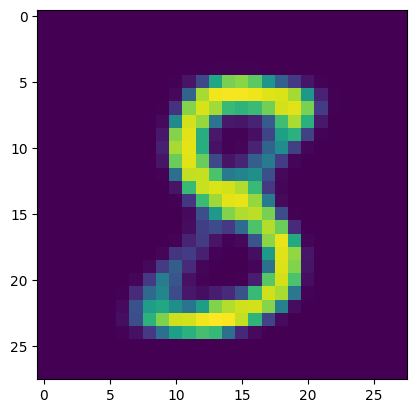

In [ ]:

def generate(model,latent_dim,num_samples=9,device="cpu"):
  model.eval()
  with torch.no_grad():
    z=torch.randn(num_samples,latent_dim).to(device)
    return model.decode(z)
genout=generate(model,20,9,device)
print(genout[1].shape,genout.shape)
imgs=genout.reshape(-1,28,28).cpu()
print(imgs.shape)
plt.imshow(imgs[0])


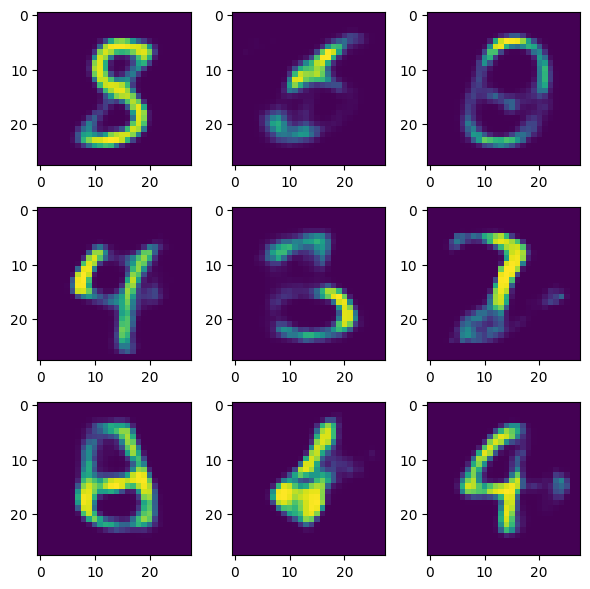

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for axis, img in zip(axes.ravel(), imgs):
    axis.imshow(img)
plt.tight_layout()
plt.show()


Some of the generated samples look similar to numbers from the original MNIST dataset. This implies the latent space contains features from the training data well. Some of the generated samples appear blurry or like a partial mix of numbers. This is due to sampling from the regions in latent space where representations of different numbers overlap, causing the decoder to create/incorprate a mix of features from different numbers.

Saving the model

In [ ]:

torch.save(model.state_dict(), "modelvae.pt")